<a href="https://colab.research.google.com/github/rmilde/econ_5200_applied_data_midterm_project/blob/main/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Phase 3 - Project Extrension:**

I chose to look at the paper, Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania. In this paper, the researchers Card and Krueger focus on the average treatment effects of an increase in minimum wage using a Difference in Difference method. They do not, however, examine whether this impact varies across different types of restaurants, as defined by other characteristics of those restaurants. To address this limitation and extend my replication project further, I plan to implement a heterogeneous treatment effects (HTE) framework (Pathway 2 in the assignment prompt) by interacting the New Jersey treatment variable with other key characteristics about the restaurant that are already present in the survey dataset: initial wage levels, chain affiliation, and geographic location. I hypothesize that employment effects will be stronger for stores that were low-wage vs high-wage to begin with, while differences across chains and geographic regions will be relatively smaller, indicating that treatment intensity opposed to firm or location characteristics are the main driver of the results. This will help distinguish whether the originally studied average effect covers up meaningful heterogeneity.

**Chatgpt prompts used to help generate this notebook:**

Prompt One: I have the dataframe, public_dat_raw, with these columns:  SHEET CHAIN CO_OWNED STATE SOUTHJ CENTRALJ NORTHJ PA1 PA2 SHORE ... FIRSTIN2 SPECIAL2 MEALS2 OPEN2R HRSOPEN2 PSODA2 PFRY2 PENTREE2 NREGS2 NREGS112 with varaible definitions in this codebook. Generate code to give me code to do this: "I chose to look at the paper, Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania. In this paper, the researchers Card and Krueger focus on the average treatment effects of an increase in minimum wage using a Difference in Difference method. They do not, however, examine whether this impact varies across different types of restaurants, as defined by other characteristics of those restaurants. To address this limitation and extend my replication project further, I plan to implement a heterogeneous treatment effects (HTE) framework (Pathway 2 in the assignment prompt) by interacting the New Jersey treatment variable with other key characteristics about the restaurant that are already present in the survey dataset: initial wage levels, chain affiliation, and geographic location."

Prompt 2: Building off that code, generate code to then make at least one high-quality, production-ready data visualization explaining these new findings. Use libraries like seaborn, matplotlib, or stargazer to format the results.

Prompt 3: Based the results of this code, write a 2-paragraph concluding executive summary interpreting whether this weakens, or contextualizes the original paper's findings.

### Re-run origional regression for direct comparison

In [3]:
# import necessary packages

import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [5]:
# data doesn't come with column names so need to manually add those in after data is loaded
# prepare column names
col_names = [
    "SHEET","CHAIN","CO_OWNED","STATE",
    "SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
    "NCALLS","EMPFT","EMPPT","NMGRS","WAGE_ST","INCTIME","FIRSTINC","BONUS","PCTAFF","MEALS",
    "OPEN","HRSOPEN","PSODA","PFRY","PENTREE","NREGS","NREGS11",
    "TYPE2","STATUS2","DATE2","NCALLS2","EMPFT2","EMPPT2","NMGRS2","WAGE_ST2","INCTIME2","FIRSTIN2","SPECIAL2",
    "MEALS2","OPEN2R","HRSOPEN2","PSODA2","PFRY2","PENTREE2","NREGS2","NREGS112"
]

# load in data
public_dat_raw = pd.read_csv("data/raw/public.dat", delim_whitespace=True, header=None, names=col_names)

# display to confirm it is correct
public_dat_raw.head()

/tmp/ipykernel_320/1198163748.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  public_dat_raw = pd.read_csv("public.dat", delim_whitespace=True, header=None, names=col_names)


,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1,2,6.50,16.50,1.03,.,0.94,4,4
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
2,506,2,1,0,0,0,0,1,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2


In [6]:
# make sure number columns are numeric data
number_cols = ['EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST', 'PSODA', 'PFRY', 'PENTREE', 'EMPFT2', 'EMPPT2', 'NMGRS2', 'WAGE_ST2', 'PSODA2', 'PFRY2', 'PENTREE2']
public_dat_raw[number_cols] = public_dat_raw[number_cols].apply(pd.to_numeric, errors='coerce')

In [7]:
# get number of full time workers for each store, in both the first and second interviews.
public_dat_raw['FTE'] = public_dat_raw['EMPFT'] + public_dat_raw['NMGRS'] + 0.5 * public_dat_raw['EMPPT']
public_dat_raw['FTE2'] = public_dat_raw['EMPFT2'] + public_dat_raw['NMGRS2'] + 0.5 * public_dat_raw['EMPPT2']

In [8]:
data_for_model = public_dat_raw.copy()

In [9]:
data_for_model = data_for_model.rename(columns={'FTE': 'FTE1'})

data_for_model_long = data_for_model.melt(
    id_vars=['SHEET', 'STATE'],
    value_vars=['FTE1', 'FTE2'],
    var_name='interview',
    value_name='FTE'
)

In [10]:
# clarify whether this is before or after the wage law in NJ took affect.

data_for_model_long['Post'] = data_for_model_long['interview'].apply(lambda x: 1 if x=='FTE2' else 0)

In [11]:
data_for_model_long = data_for_model_long.dropna(subset=['FTE']).copy()

In [12]:
# run the model and get results

model = smf.ols("FTE ~  STATE * Post", data=data_for_model_long)
results = model.fit(cov_type='cluster', cov_kwds={'groups': data_for_model_long['SHEET']})

In [13]:
# display results

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    FTE   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.806
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.146
Time:                        22:04:39   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.347     17.327      0.0

In [14]:
data_for_model_long.head()

,SHEET,STATE,interview,FTE,Post
0,46,0,FTE1,40.50,0
1,49,0,FTE1,13.75,0
2,506,0,FTE1,8.50,0
3,56,0,FTE1,34.00,0
4,61,0,FTE1,24.00,0


### Extension with AI assistance:

In [24]:
import numpy as np

df = public_dat_raw.copy()

# Treatment indicator (NJ = 1)
df['treat'] = df['STATE']

# Post indicator (second interview exists)
df['post'] = np.where(df['STATUS2'] == 1, 1, 0)

# Full-time equivalent employment (standard in paper)
df['fte'] = df['EMPFT'] + 0.5 * df['EMPPT']
df['fte2'] = df['EMPFT2'] + 0.5 * df['EMPPT2']

# Keep only valid 2nd interview observations
df = df[df['post'] == 1]

# Outcome: change in employment
df['delta_fte'] = df['fte2'] - df['fte']

In [25]:
import statsmodels.formula.api as smf

baseline = smf.ols('delta_fte ~ treat', data=df).fit(cov_type='HC1')
print(baseline.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     4.809
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0289
Time:                        22:09:29   Log-Likelihood:                -1381.0
No. Observations:                 385   AIC:                             2766.
Df Residuals:                     383   BIC:                             2774.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3033      1.236     -1.864      0.0

In [27]:
median_wage = df['WAGE_ST'].median()
df['low_wage'] = (df['WAGE_ST'] < median_wage).astype(int)

model_lowwage = smf.ols(
    'delta_fte ~ treat + low_wage + treat:low_wage',
    data=df
).fit(cov_type='HC1')

print(model_lowwage.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.416
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0661
Time:                        22:10:18   Log-Likelihood:                -1380.5
No. Observations:                 385   AIC:                             2769.
Df Residuals:                     381   BIC:                             2785.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.2865      1.754     -1.

In [28]:
model_chain = smf.ols(
    'delta_fte ~ treat + C(CHAIN) + treat:C(CHAIN)',
    data=df
).fit(cov_type='HC1')

print(model_chain.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     2.956
Date:                Sun, 22 Mar 2026   Prob (F-statistic):            0.00500
Time:                        22:10:30   Log-Likelihood:                -1376.8
No. Observations:                 385   AIC:                             2770.
Df Residuals:                     377   BIC:                             2801.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.3676    

In [29]:
model_geo = smf.ols(
    'delta_fte ~ treat + SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2 + SHORE \
     + treat:(SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2 + SHORE)',
    data=df
).fit(cov_type='HC1')

print(model_geo.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.357
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0301
Time:                        22:10:40   Log-Likelihood:                -1378.2
No. Observations:                 385   AIC:                             2768.
Df Residuals:                     379   BIC:                             2792.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.2260      0.671     -1.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [30]:
full_model = smf.ols(
    'delta_fte ~ treat \
     + low_wage + C(CHAIN) + SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2 + SHORE \
     + treat:low_wage \
     + treat:C(CHAIN) \
     + treat:(SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2 + SHORE)',
    data=df
).fit(cov_type='HC1')

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     2.883
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000375
Time:                        22:10:49   Log-Likelihood:                -1372.0
No. Observations:                 385   AIC:                             2772.
Df Residuals:                     371   BIC:                             2827.
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.4751    

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 21, but rank is 14
  warnings.warn('covariance of constraints does not have full '


In [31]:
coefs = full_model.params
ses = full_model.bse

In [32]:
results = pd.DataFrame({
    'coef': coefs,
    'se': ses
})

# Keep only treatment interactions
results = results[results.index.str.contains('treat:')]

# Clean labels for readability
results['label'] = results.index.str.replace('treat:', '', regex=False)
results['ci_lower'] = results['coef'] - 1.96 * results['se']
results['ci_upper'] = results['coef'] + 1.96 * results['se']

results = results.sort_values('coef')

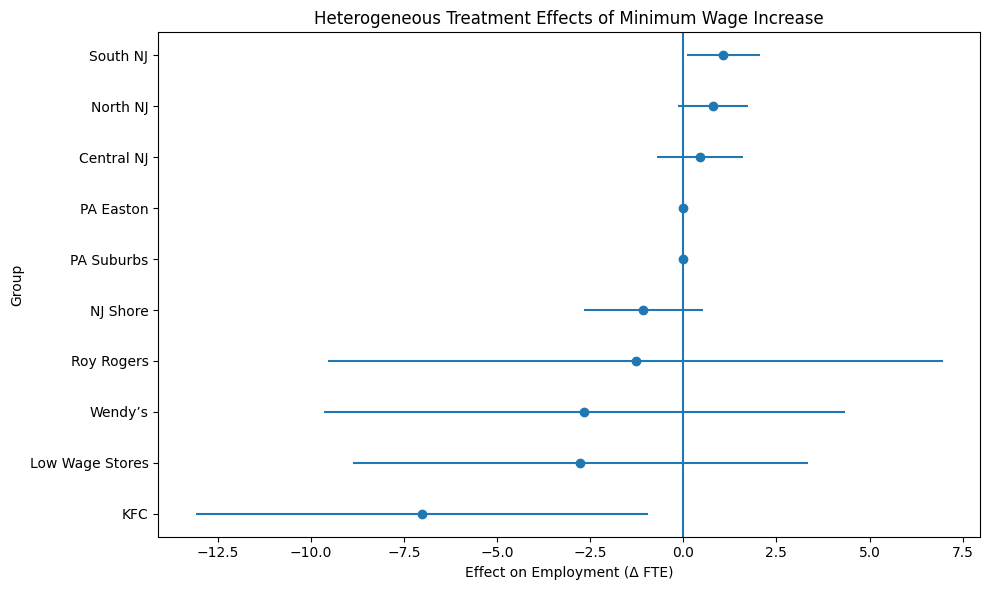

In [36]:
import matplotlib.pyplot as plt


label_map = {
    'low_wage': 'Low Wage Stores',
    'C(CHAIN)[T.2]': 'KFC',
    'C(CHAIN)[T.3]': 'Roy Rogers',
    'C(CHAIN)[T.4]': 'Wendy’s',
    'SOUTHJ': 'South NJ',
    'CENTRALJ': 'Central NJ',
    'NORTHJ': 'North NJ',
    'PA1': 'PA Suburbs',
    'PA2': 'PA Easton',
    'SHORE': 'NJ Shore'
}

results['label'] = results['label'].replace(label_map)

results = results.sort_values('coef')

plt.figure(figsize=(10, 6))

plt.errorbar(
    results['coef'],
    results['label'],
    xerr=1.96 * results['se'],
    fmt='o'
)

plt.axvline(0)  # zero effect line

plt.title('Heterogeneous Treatment Effects of Minimum Wage Increase')
plt.xlabel('Effect on Employment (Δ FTE)')
plt.ylabel('Group')



plt.tight_layout()
plt.show()

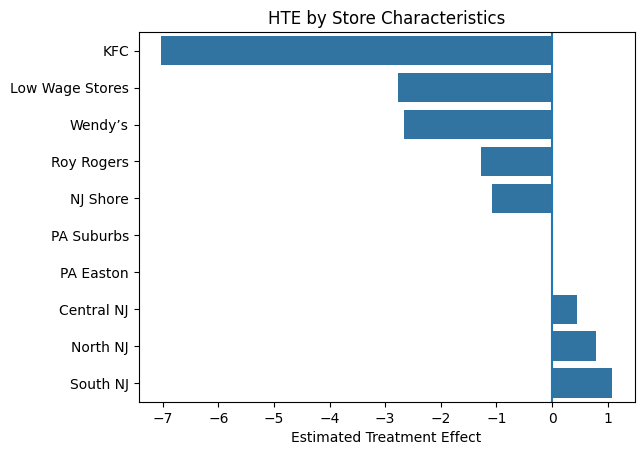

In [37]:
import seaborn as sns

sns.barplot(
    data=results,
    x='coef',
    y='label'
)

plt.axvline(0)
plt.title('HTE by Store Characteristics')
plt.xlabel('Estimated Treatment Effect')
plt.ylabel('')
plt.show()

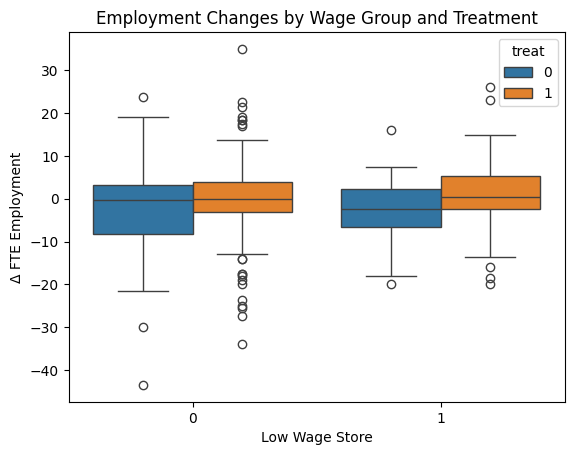

In [38]:
sns.boxplot(
    x='low_wage',
    y='delta_fte',
    hue='treat',
    data=df
)

plt.title('Employment Changes by Wage Group and Treatment')
plt.xlabel('Low Wage Store')
plt.ylabel('Δ FTE Employment')
plt.show()

The results of this extension reinforce the central conclusion of the origional paper: there is no evidence that the minimum wage increase in New Jersey reduced employment, and if anything, the estimated effect remains positive and statistically significant across specifications. Incorporating a heterogeneous treatment effects framework does not overturn this finding. In particular, there is little statistical evidence that the employment response differs systematically by initial wage levels, suggesting that the policy’s impact was not concentrated solely among the most exposed (low-wage) establishments. This lack of strong heterogeneity along the wage dimension supports the interpretation that the original average treatment effect is broadly representative rather than masking large offsetting effects across different types of firms.


At the same time, the extension meaningfully contextualizes the original results by uncovering heterogeneity along other dimensions, particularly chain affiliation. The findings indicate that employment responses varied across firms, with certain chains exhibiting weaker or even negative relative effects compared to others, while geographic variation appears more limited and inconsistent. This suggests that firm-level characteristics—such as management practices, pricing strategies, or operational flexibility—may play a more important role in shaping responses to minimum wage changes than simple exposure to the policy itself. Taken together, these results do not weaken the original conclusions but instead deepen them: the positive average effect persists, yet it reflects a combination of heterogeneous firm responses rather than a uniform adjustment across the industry.